In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [43]:
# Load a complex dataset
df = pd.read_csv('airline_passenger_satisfaction.csv')

# Exploratory Data Analysis

In [44]:
from ydata_profiling import ProfileReport

# Generate the report
profile = ProfileReport(df, title="Airline Passenger Satisfaction Report", explorative=True)

# Save it to view
profile.to_file("airline_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:00<00:00, 74.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Data Cleaning

In [45]:
# Strip whitespace, lower case, replace spaces/hyphens, remove punctuation
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "")
    .str.replace(r"[()$]", "", regex=True)
)

In [46]:
df['arrival_delay'] = df['arrival_delay'].fillna(0)

In [47]:
# Replace 0 with NaN to exclude from aggregations
satisfaction_level_columns = ['departure_and_arrival_time_convenience',
                                  'ease_of_online_booking', 'checkin_service', 'online_boarding', 
                                  'gate_location', 'onboard_service', 'seat_comfort', 
                                  'leg_room_service', 'cleanliness', 'food_and_drink', 
                                  'inflight_service', 'inflight_wifi_service', 'inflight_entertainment', 'baggage_handling']

for i in satisfaction_level_columns:
    df[i] = df[i].replace(0, np.nan)

In [48]:
# Segment age into groups
def age_group(age):
    if age < 18:
        return '<18'
    elif 18 <= age <= 30:
        return '18-30'
    elif 31 <= age <= 40:
        return '31-40'
    elif 41 <= age <= 50:
        return '41-50'
    elif 51 <= age <= 60:
        return '51-60'
    else:
        return '>60'

df['age_group'] = df['age'].apply(age_group)

In [49]:
# Convert from minutes to hours 
convert_to_hrs = ['departure_delay', 'arrival_delay']
for i in convert_to_hrs:
    df[i] = (df[i] / 60).round(2)

In [50]:
delay_bins = [-0.01, 0, 1, 3, 6, 12, 18, float('inf')]
delay_labels = ['No Delay', 'Delay <1 hr', 'Delay <3 hrs', 'Delay <6 hrs', 'Delay <12 hrs', 'Delay <18 hrs', 'Delay 1 day+']

for i in convert_to_hrs:
    df[f'{i}_bucket'] = pd.cut(df[i], bins=delay_bins, labels=delay_labels, right=True)

In [51]:
# Generate the report
profile = ProfileReport(df, title="Airline Passenger Satisfaction Report", explorative=True)

# Save it to view
profile.to_file("cleaned_airline_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 27/27 [00:02<00:00, 13.29it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [52]:
df.to_csv('cleaned_airline_passenger_satisfaction.csv', index=False)

# Data Analysis

In [17]:
satisfaction_rate = df['satisfaction'].value_counts(normalize=True).round(4) * 100
satisfaction_rate

satisfaction
Neutral or Dissatisfied    56.55
Satisfied                  43.45
Name: proportion, dtype: float64

In [ ]:
satisfaction_customer_type = (
    df.groupby('customer_type')['satisfaction']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)
satisfaction_customer_type

satisfaction,Neutral or Dissatisfied,Satisfied
customer_type,,
First-time,76.03,23.97
Returning,52.19,47.81


NameError: name 'satisfaction_customer_type' is not defined

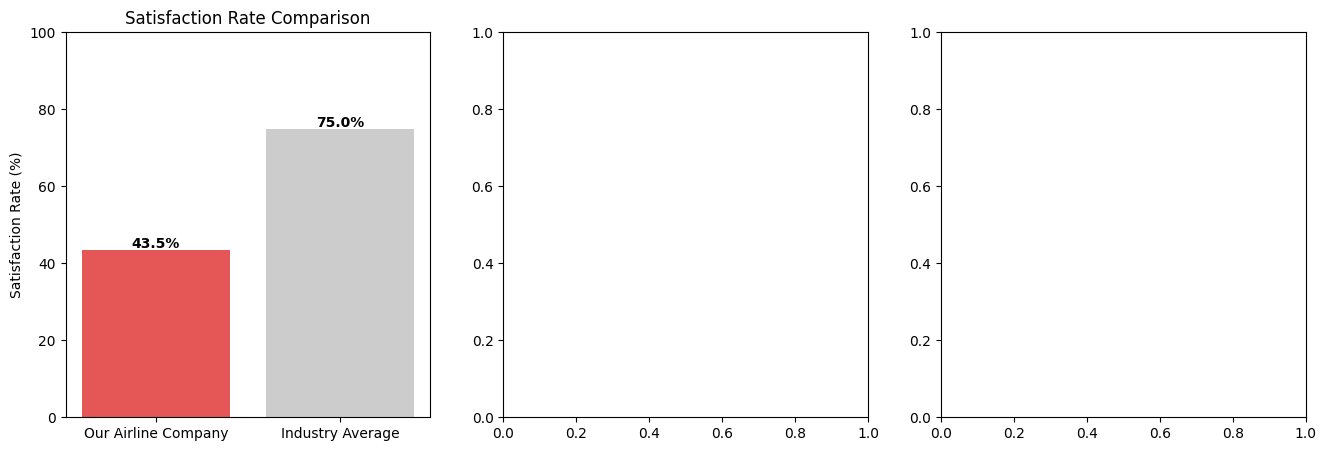

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# vs Benchmark
axes[0].bar(["Our Airline Company", "Industry Average"], [satisfaction_rate, 75], color=["#E45756", "#CCCCCC"])
axes[0].set_title("Satisfaction Rate Comparison")
axes[0].set_ylabel("Satisfaction Rate (%)")
axes[0].set_ylim(0, 100)
for i, v in enumerate([satisfaction_rate, 75]):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

# vs Customer Type (stacked)
colors = {'Satisfied': '#54A24B', 'Neutral or Dissatisfied': '#CCCCCC'}

left = pd.Series(0, index=satisfaction_pct.index)
for col, color in colors.items():
    axes[1].barh(satisfaction_pct.index, satisfaction_pct[col], left=left, color=color, label=col)
    left += satisfaction_pct[col]

axes[1].set_title("Satisfaction Rate by Customer Type")
axes[1].set_xlabel("Percentage (%)")
axes[1].set_xlim(0, 100)
axes[1].legend(loc="lower right")

for i, v in enumerate(satisfaction_pct['Satisfied']):
    axes[1].text(v / 2, i, f"{v:.1f}%", va="center", ha="center", fontweight="bold", color="white")

    

plt.suptitle("The 'Compared to What?' Trifecta", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


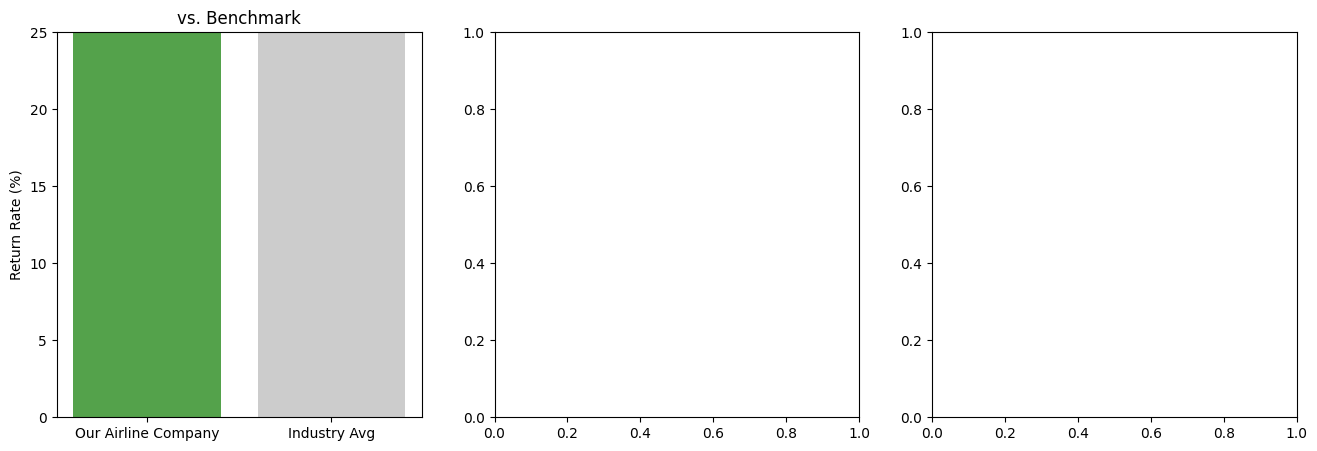

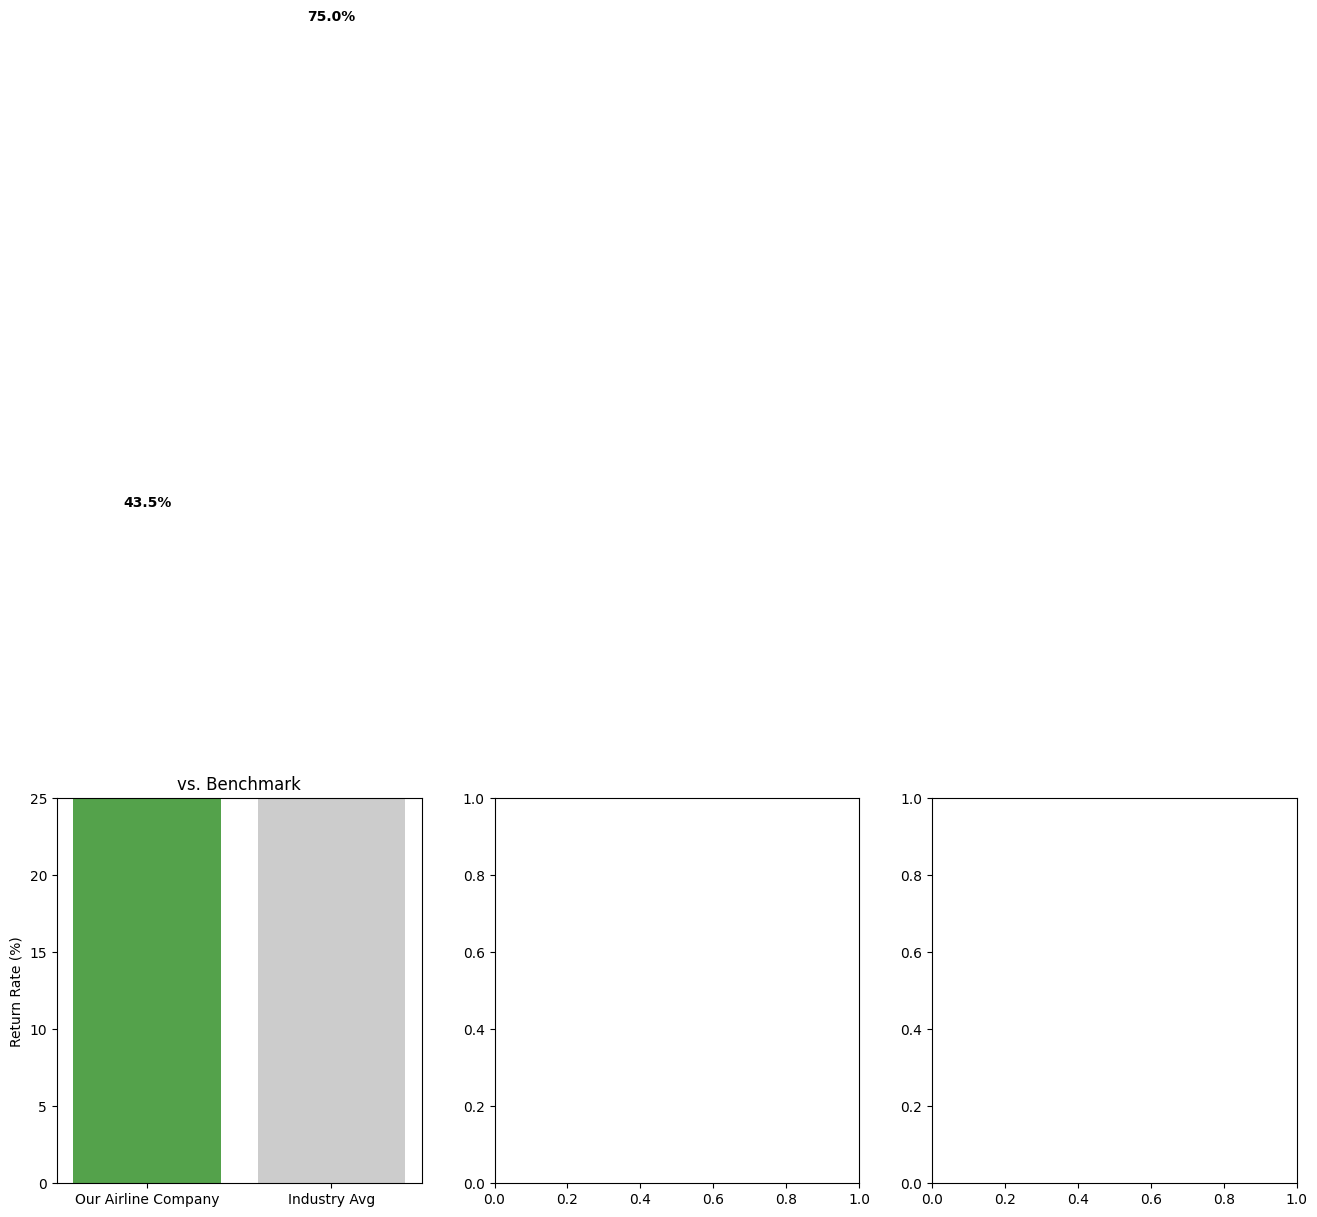

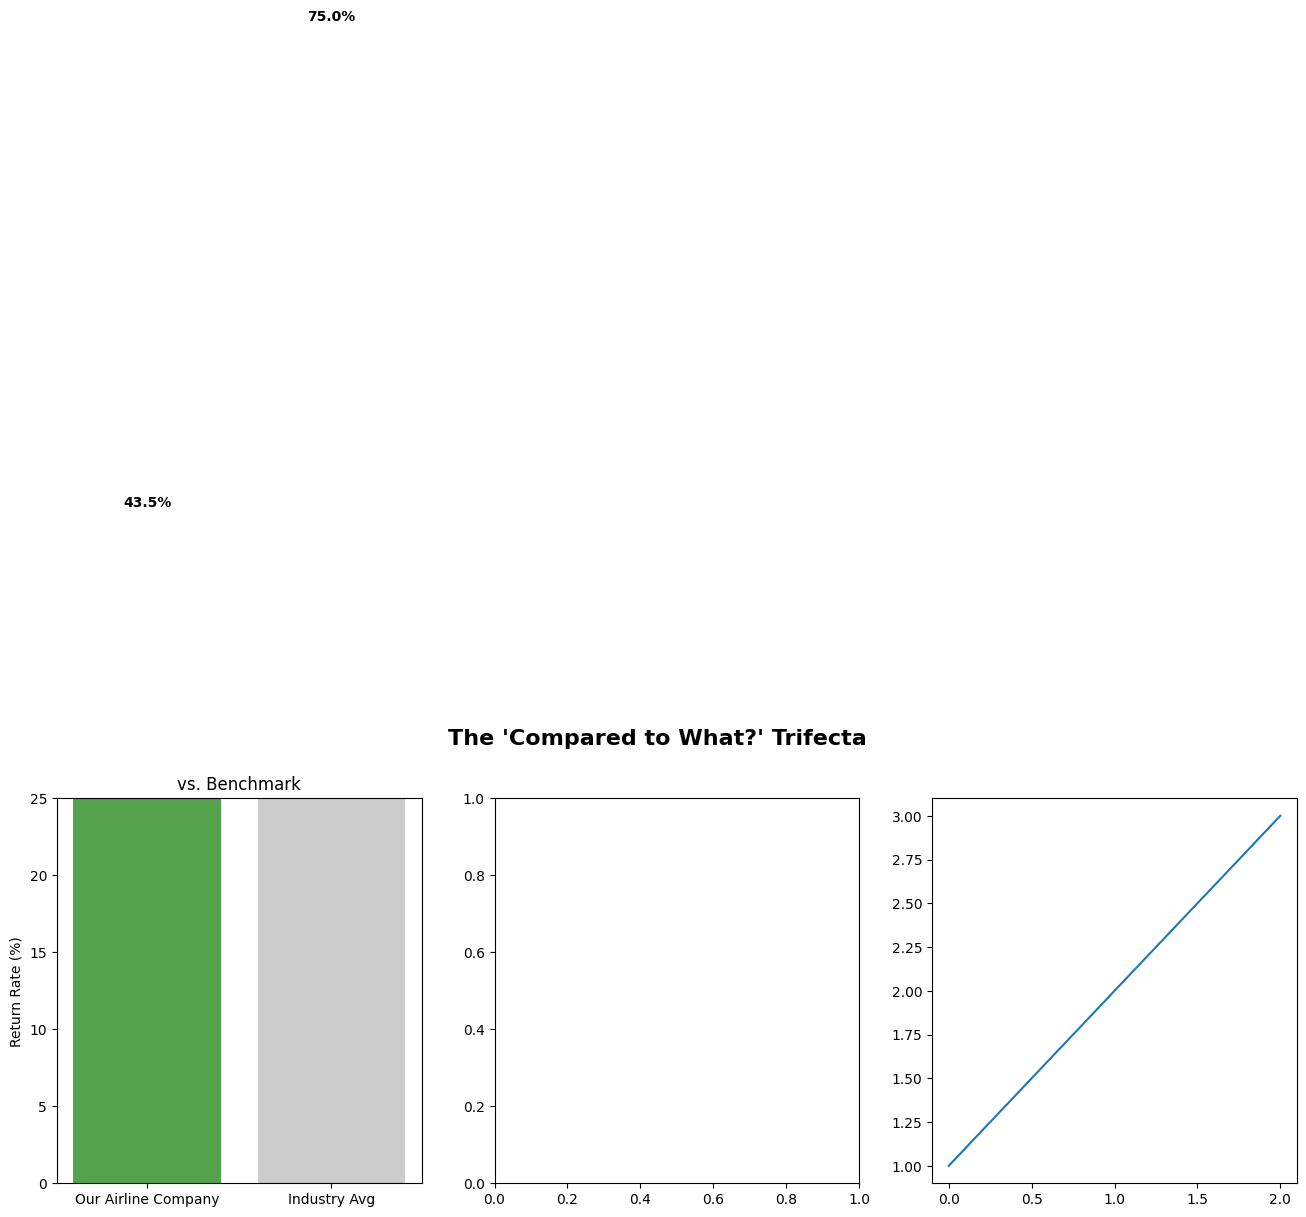

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot([1,2,3])
plt.show()
